# Build Caco2 (A->Papp) DL model.

This notebook shows how to build an DL model to predict Caco-2 A->B Papp as a proxity for permeability. 

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, global_mean_pool
from torch_geometric.data import Data, Batch

from rdkit import Chem
from rdkit.Chem import Descriptors, rdPartialCharges
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold

import itertools
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import pathlib
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#verify Cuda is actually working

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version (runtime):", torch.version.cuda)

print("Torch CUDA libraries loaded:")
for lib in torch.cuda._CudaBase.__module__.split(":"):
    print(lib)

Torch version: 2.8.0+cu128
CUDA available: True
CUDA version (runtime): 12.8
Torch CUDA libraries loaded:
torch.cuda


## Setup.

In [5]:
readout = 'caco2_abpapp'

In [6]:
# define paths
HERE = Path(pathlib.Path.cwd())
DATA = HERE / f"data_{readout}"
DATA.mkdir(parents=True, exist_ok=True)

In [7]:
# Load chembl data

df = pd.read_csv(f'{DATA}/{readout}_chembl.csv',index_col=None)
df.head(5)

,Unnamed: 0,activity_id,assay_chembl_id,molecule_chembl_id,type,standard_units,relation,standard_value,target_chembl_id,target_organism,assay_description,assay_type,smiles,error
0,0,25864927,CHEMBL5511234,CHEMBL5557642,Papp,10^-6 cm/s,=,8.6,CHEMBL612558,NaN,Apparent permeability across apical to basal s...,A,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(Nc4cccc(O)c4)ncn...,NaN
1,1,25864928,CHEMBL5511235,CHEMBL5557642,Papp,10^-6 cm/s,=,8.0,CHEMBL612558,NaN,Apparent permeability across apical to basal s...,A,CC(=O)OC[C@H]1O[C@@H](n2cnc3c(Nc4cccc(O)c4)ncn...,NaN
2,2,25865165,CHEMBL5511286,CHEMBL5559507,permeability,10^-6 cm/s,=,16.3,CHEMBL612558,NaN,Passive permeability in human Caco-2 cells,A,Cc1ccc(CN2CCCCC2)cc1-c1noc(C)c1-c1ccc2c(c1)OCC...,NaN
3,3,25865391,CHEMBL5511341,CHEMBL5555218,Papp,10^-6 cm/s,=,1.9,CHEMBL612558,NaN,Apparent permeability across apical to basolat...,A,CC[N+]1(C)CCN(c2ccc(C(=O)Nc3cccc(C)n3)cc2)CC1....,NaN
4,4,25865392,CHEMBL5511341,CHEMBL5558610,Papp,10^-6 cm/s,=,2.5,CHEMBL612558,NaN,Apparent permeability across apical to basolat...,A,CC[N+]1(C)CCN(c2ccc(NC(=O)c3cccc(C)n3)cc2)CC1....,NaN


In [8]:
len(df)

3221

In [9]:
# Remove NaN Papps (should have been done already)
df = df[df['standard_value'].notnull() & np.isfinite(df['standard_value'])]
len(df)

3221

Is the dataset balanced?

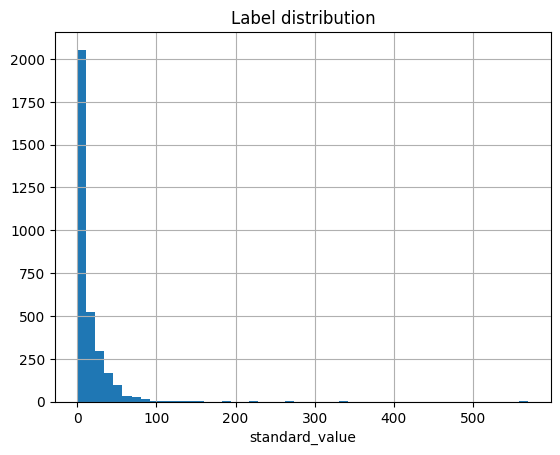

In [10]:
plt.hist(df['standard_value'], bins=50)
plt.xlabel("standard_value")
plt.title("Label distribution")
plt.grid(True)
plt.savefig("_images/sample_balance.png", dpi=300)
plt.show()

The dataset is clearly unbalanced (centred on relatively low Papp, which is expected) - need to take a balanced sample.

In [11]:
def stratified_balanced_sampling(df, label_col='standard_value', n_bins=20, max_samples_per_bin=500, random_state=42):
    """
    Stratified sampling to balance dataset by label distribution.

    Args:
        df (pd.DataFrame): DataFrame containing labelled data.
        label_col (str): Name of the label column (e.g., 'pIC50').
        n_bins (int): Number of bins to discretize the label.
        max_samples_per_bin (int): Maximum number of samples to keep per bin.
        random_state (int): Random seed for reproducibility.

    Returns:
        pd.DataFrame: Balanced DataFrame sampled from input.
    """
    np.random.seed(random_state)
    
    # Create bins
    bins = np.linspace(df[label_col].min(), df[label_col].max(), n_bins + 1)
    df['bin'] = pd.cut(df[label_col], bins=bins, include_lowest=True, labels=False)

    balanced_indices = []

    for bin_id in range(n_bins):
        bin_indices = df[df['bin'] == bin_id].index.values
        n_samples = len(bin_indices)

        if n_samples == 0:
            continue
        
        if n_samples > max_samples_per_bin:
            chosen = np.random.choice(bin_indices, max_samples_per_bin, replace=False)
        else:
            chosen = np.random.choice(bin_indices, max_samples_per_bin, replace=True)

        balanced_indices.extend(chosen)

    # Create balanced dataset
    balanced_df = df.loc[balanced_indices].reset_index(drop=True)

    balanced_df = balanced_df.drop(columns=['bin'])

    return balanced_df

In [12]:
# Take a balanced sample before generating datasets for training
balanced_df = stratified_balanced_sampling(df, label_col='standard_value', n_bins=20, max_samples_per_bin=500)

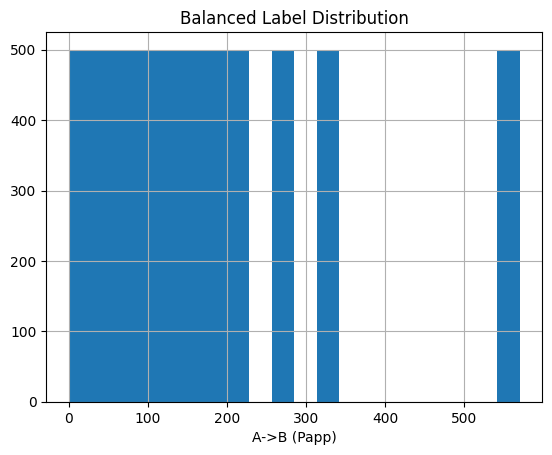

In [13]:
# Is the dataset now balanced?

plt.hist(balanced_df['standard_value'], bins=20)
plt.xlabel("A->B (Papp)")
plt.title("Balanced Label Distribution")
plt.grid(True)
plt.show()

In [16]:
smiles_list = balanced_df['smiles'].tolist()
pic50_values = balanced_df['standard_value'].tolist()

Pytorch geometric fix

In [17]:
# Here we define our own data structure for Pytorch Geometric to use in the model.
# Why? In the functions below, PyG's Batch.from_data_list tries to automatically 
# concatenate all descriptors and layers and gets the feature vector size wrong unless instructed not to. 
# (1D vector of 288 instead of 2D vector odf 32 x 9 chemical features)  
# global_features should be stacked (batched), not concatenated - the __cat_dim__ method controls that.

class MoleculeData(Data):
    def __inc__(self, key, value, *args, **kwargs):
        return super().__inc__(key, value)

    def __cat_dim__(self, key, value, *args, **kwargs):
        if key == 'global_features':
            return None  # do not concatenate along any dimension
        return super().__cat_dim__(key, value)


In [18]:
def safe_value(val):
    try:
        if np.isnan(val) or np.isinf(val):
            return 0.0
        return val
    except:
        return 0.0

## Featurisation step.

In [19]:
# Let's try with the same descriptors as CYP and see how we go.

descriptor_functions = [
    Descriptors.MolWt,
    Descriptors.MolLogP,
    Descriptors.NumHDonors,
    Descriptors.NumHAcceptors,
    Descriptors.TPSA,
    Descriptors.FractionCSP3,
    Descriptors.HeavyAtomCount,
    Descriptors.NumRotatableBonds,
    Descriptors.RingCount
]

# Precompute a dict of electronegativities (Pauling scale)
electronegativity_dict = {
    1: 2.20, 6: 2.55, 7: 3.04, 8: 3.44, 9: 3.98, 15: 2.19,
    16: 2.58, 17: 3.16, 35: 2.96, 53: 2.66,
}

# List of metals by atomic number (common metals)
metals = {
    3, 4, 11, 12, 13, 19, 20, 21, 22, 23, 24, 25,
    26, 27, 28, 29, 30, 37, 38, 39, 40, 41, 42,
    43, 44, 45, 46, 47, 48, 49, 55, 56, 57, 72,
    73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83,
    87, 88, 89, 104, 105, 106, 107, 108, 109, 110,
    111, 112, 113, 114, 115, 116
}

def one_hot_encoding(x, allowable_set):
    if x not in allowable_set:
        x = allowable_set[-1]  # fallback to "unknown"
    return [int(x == s) for s in allowable_set]

def get_atom_features(atom, mol=None):
    pt = Chem.GetPeriodicTable()
    features = []

    # Atom symbol (one-hot + unknown)
    features += one_hot_encoding(atom.GetSymbol(),
                                ['C', 'N', 'O', 'F', 'P', 'S', 'Cl', 'Br', 'I', 'H',
                                 'B', 'Si', 'Se', 'As', 'Al', 'Zn', 'Cu', 'Ni', 'Fe', 'other'])

    # Hybridization (one-hot)
    features += one_hot_encoding(atom.GetHybridization(),
                                [Chem.rdchem.HybridizationType.SP,
                                 Chem.rdchem.HybridizationType.SP2,
                                 Chem.rdchem.HybridizationType.SP3,
                                 Chem.rdchem.HybridizationType.SP3D,
                                 Chem.rdchem.HybridizationType.SP3D2,
                                 Chem.rdchem.HybridizationType.UNSPECIFIED])

    # Integer-valued features (can be scaled later if needed)
    features += [
        atom.GetDegree(),               # n_bonded neighbors
        atom.GetFormalCharge(),
        atom.GetNumRadicalElectrons(),
        int(atom.GetIsAromatic())
    ]

    atomic_num = atom.GetAtomicNum()

    # Physical properties from periodic table (normalised to 0-1)
    # We could prpbably play with this, if we want to.
    features += [
        pt.GetAtomicWeight(atomic_num) / 200,                 # ~1–200 → 0–1
        pt.GetRvdw(atomic_num) / 2.5,                         # ~0.5–2.5 → 0–1
        electronegativity_dict.get(atomic_num, 0.0) / 4.0,    # ~0–4 → 0–1
        pt.GetNOuterElecs(atomic_num) / 8.0,                  # Valence electrons, ~0–8
        1.0 if atomic_num in metals else 0.0                  # binary
    ]


    # Partial charge (Gasteiger)
    # Something else we could play with (e.g. AM1-BCC) but this adds cost.
    if mol is not None:
        try:
            charge = float(atom.GetProp('_GasteigerCharge'))
            charge = safe_value(charge)
            if np.isnan(charge) or np.isinf(charge):
                charge = 0.0
        except:
            charge = 0.0
        features += [charge]
    else:
        features += [0.0]

    return np.array(features, dtype=np.float32)

def get_bond_features(bond):
    bond_type = bond.GetBondType()
    features = [
        int(bond_type == Chem.rdchem.BondType.SINGLE),
        int(bond_type == Chem.rdchem.BondType.DOUBLE),
        int(bond_type == Chem.rdchem.BondType.TRIPLE),
        int(bond_type == Chem.rdchem.BondType.AROMATIC),
        int(bond.GetIsConjugated()),
        int(bond.IsInRing()),
    ]
    return np.array(features, dtype=np.float32)


## Convert Featurised molecules into graph for the model.

In [32]:
def mol_to_graph(smiles: str, label: float = None):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    try:
        rdPartialCharges.ComputeGasteigerCharges(mol)
    except:
        pass

    atom_features = [get_atom_features(atom, mol) for atom in mol.GetAtoms()]
    x = torch.tensor(atom_features, dtype=torch.float)

    edge_index = []
    edge_attr = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        bond_feat = get_bond_features(bond)
        edge_index += [[i, j], [j, i]]
        edge_attr += [bond_feat, bond_feat]

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    global_features = []
    for func in descriptor_functions:
        try:
            val = func(mol)
            val = safe_value(val)
        except:
            val = 0.0
        global_features.append(val)
    global_features = torch.tensor(global_features, dtype=torch.float32)

    # Use MoleculeData class we added here instead of Data
    data = MoleculeData(x=x, edge_index=edge_index, edge_attr=edge_attr, global_features=global_features)

    if label is not None:
        data.y = torch.tensor([label], dtype=torch.float)
    
    data.smiles = smiles

    return data


Data loader code.

In [33]:
# We have to tell the DataLoader which features to expect.

def compute_global_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        # fallback vector of zeros if mol fails
        return torch.zeros(len(descriptor_functions), dtype=torch.float)
    feats = [fn(mol) for fn in descriptor_functions]
    return torch.tensor(feats, dtype=torch.float)

In [34]:
def custom_collate(batch_list):
    return Batch.from_data_list(batch_list)

In [35]:
# Create data list
data_list = []
for smi, lbl in zip(smiles_list, pic50_values):
    data = mol_to_graph(smi, label=lbl)
    if data is not None:
        data_list.append(data)

from torch_geometric.loader import DataLoader

loader = DataLoader(data_list, batch_size=16, shuffle=True, collate_fn=custom_collate)

## The Regression model definition.

In [36]:
# Same model as CYP3A4

class GINRegressor(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim=64, global_feat_dim=0):
        super().__init__()

        nn1 = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim))
        nn2 = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim))

        self.conv1 = GINConv(nn1)
        self.conv2 = GINConv(nn2)

        self.lin = nn.Sequential(
            nn.Linear(hidden_dim + global_feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)

        x = global_mean_pool(x, batch)

        if hasattr(data, 'global_features'):
            global_feat = data.global_features.to(x.device)
            x = torch.cat([x, global_feat], dim=1)

        return self.lin(x).squeeze(1)

## Training loop.

With train / val split, early stopping and grid search.

In [37]:
from sklearn.model_selection import train_test_split

train_list, val_list = train_test_split(data_list, test_size=0.2, random_state=42)

train_loader = DataLoader(train_list, batch_size=32, shuffle=True, collate_fn=custom_collate)
val_loader = DataLoader(val_list, batch_size=32, shuffle=False, collate_fn=custom_collate)


In [38]:
def train_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch)
        loss = loss_fn(out, batch.y.to(device).float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader, loss_fn):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch)
            loss = loss_fn(out, batch.y.to(device).float())
            total_loss += loss.item()
            all_preds.append(out.cpu())
            all_labels.append(batch.y.cpu())
    return total_loss / len(loader), torch.cat(all_preds), torch.cat(all_labels)

In [39]:
def train_with_early_stopping(params):
    model = GINRegressor(
        input_dim=params['input_dim'],
        hidden_dim=params['hidden_dim'],
        global_feat_dim=params.get('global_feat_dim', 0)
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
    loss_fn = torch.nn.MSELoss()

    best_val_loss = float('inf')
    patience = 10
    counter = 0

    train_losses = []
    val_losses = []

    for epoch in range(100):
        train_loss = train_epoch(model, train_loader, optimizer, loss_fn)
        val_loss, _, _ = eval_epoch(model, val_loader, loss_fn)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            counter += 1

        if counter >= patience:
            print("Early stopping triggered.")
            break

    model.load_state_dict(torch.load('best_model.pth'))

    # Plot loss curves
    plt.figure(figsize=(8,5))
    plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss')
    plt.plot(range(1, len(val_losses)+1), val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves')
    plt.legend()
    plt.show()

    return model

With hyperparameter tuning.


Training with lr=0.001, hidden_dim=64
Epoch 1 | Train: 27077.6420 | Val: 22643.1724
Epoch 2 | Train: 21601.0687 | Val: 21133.4462
Epoch 3 | Train: 17928.1505 | Val: 13181.5304
Epoch 4 | Train: 11303.5842 | Val: 12160.7034
Epoch 5 | Train: 9902.3667 | Val: 10202.1439
Epoch 6 | Train: 9356.9725 | Val: 8876.5794
Epoch 7 | Train: 8844.8127 | Val: 8603.1935
Epoch 8 | Train: 8342.5849 | Val: 7984.8626
Epoch 9 | Train: 8016.1738 | Val: 7388.8143
Epoch 10 | Train: 7737.8742 | Val: 7197.9379
Epoch 11 | Train: 7130.9124 | Val: 6565.6301
Epoch 12 | Train: 6529.6523 | Val: 6482.9396
Epoch 13 | Train: 6151.6041 | Val: 5537.6717
Epoch 14 | Train: 5955.4008 | Val: 5261.2750
Epoch 15 | Train: 5576.6712 | Val: 4840.3074
Epoch 16 | Train: 5335.8063 | Val: 4533.3504
Epoch 17 | Train: 5100.1894 | Val: 4474.6020
Epoch 18 | Train: 4870.8440 | Val: 4272.3989
Epoch 19 | Train: 4486.0893 | Val: 4180.6103
Epoch 20 | Train: 4476.3951 | Val: 4217.5416
Epoch 21 | Train: 4316.2408 | Val: 3812.8907
Epoch 22 | Train

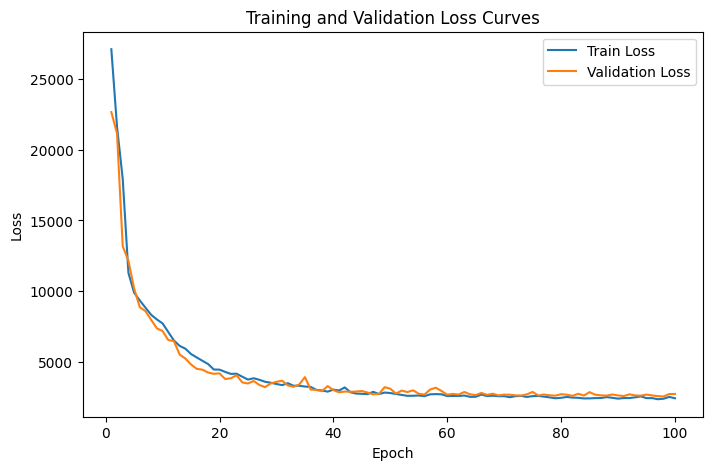


Training with lr=0.001, hidden_dim=128
Epoch 1 | Train: 25497.4618 | Val: 22123.5007
Epoch 2 | Train: 19105.3257 | Val: 13267.5520
Epoch 3 | Train: 10980.5582 | Val: 9931.7167
Epoch 4 | Train: 10261.5307 | Val: 9882.5464
Epoch 5 | Train: 9659.1204 | Val: 9234.3774
Epoch 6 | Train: 9055.0233 | Val: 8600.8078
Epoch 7 | Train: 8945.2457 | Val: 7806.2491
Epoch 8 | Train: 7948.4316 | Val: 6960.5895
Epoch 9 | Train: 7296.9321 | Val: 6879.4420
Epoch 10 | Train: 6866.7617 | Val: 7234.6541
Epoch 11 | Train: 6692.9902 | Val: 6027.2330
Epoch 12 | Train: 6166.2723 | Val: 5119.8581
Epoch 13 | Train: 5046.5644 | Val: 4532.0089
Epoch 14 | Train: 4547.0728 | Val: 4337.1874
Epoch 15 | Train: 4307.6969 | Val: 4376.5058
Epoch 16 | Train: 4083.8817 | Val: 3814.0816
Epoch 17 | Train: 3984.4980 | Val: 3953.6613
Epoch 18 | Train: 4133.9955 | Val: 4568.8780
Epoch 19 | Train: 3745.7681 | Val: 3732.6707
Epoch 20 | Train: 3704.0360 | Val: 3923.1823
Epoch 21 | Train: 3707.4599 | Val: 3445.5290
Epoch 22 | Train: 

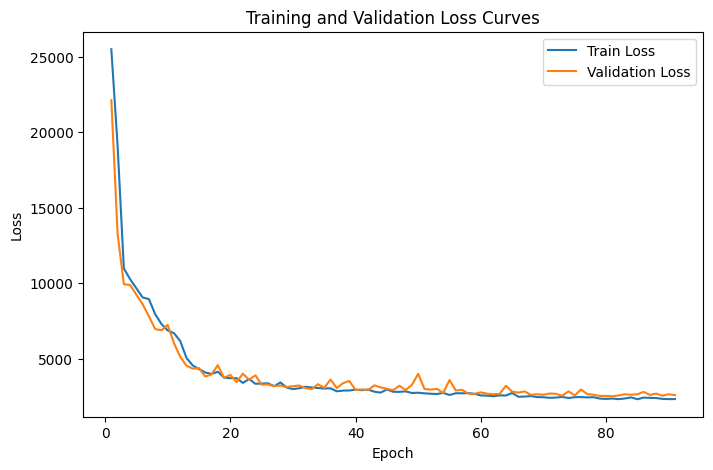

Best params: {'lr': 0.001, 'hidden_dim': 128, 'input_dim': 36, 'global_feat_dim': 9}


In [40]:
input_dim = data_list[0].x.shape[1]
global_feat_dim = len(descriptor_functions)

param_grid = {
    'lr': [0.001],
    'hidden_dim': [64, 128],
}

best_model = None
best_loss = float('inf')
best_params = None

for lr, hidden_dim in itertools.product(param_grid['lr'], param_grid['hidden_dim']):
    print(f"\nTraining with lr={lr}, hidden_dim={hidden_dim}")
    params = {
        'lr': lr,
        'hidden_dim': hidden_dim,
        'input_dim': input_dim,
        'global_feat_dim': global_feat_dim
    }
    model = train_with_early_stopping(params)
    val_loss, _, _ = eval_epoch(model, val_loader, torch.nn.MSELoss())

    if val_loss < best_loss:
        best_loss = val_loss
        best_model = model
        best_params = params

print(f"Best params: {best_params}")

## Evaluation


Best params: {'lr': 0.001, 'hidden_dim': 128, 'input_dim': 36, 'global_feat_dim': 9}

RMSE: 47.7742
MAE: 18.4958
R²: 0.9062


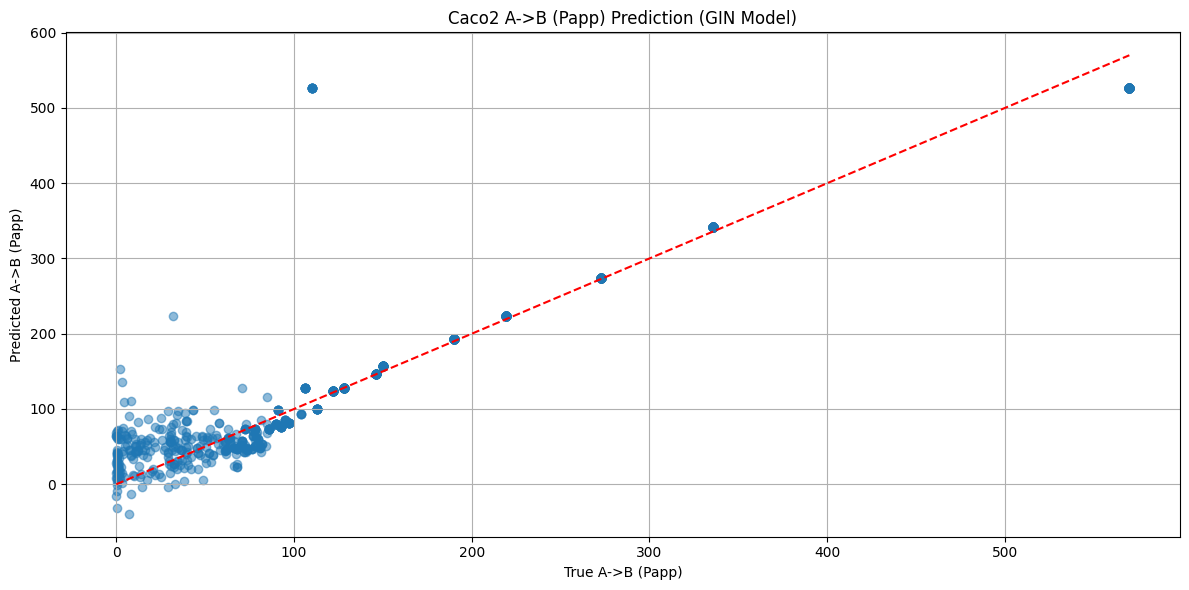

In [41]:
print(f"\nBest params: {best_params}")

y_true = []
y_pred = []

with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        pred = best_model(batch)
        y_true.extend(batch.y.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"\nRMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

plt.figure(figsize=(12, 6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
plt.xlabel("True A->B (Papp)")
plt.ylabel("Predicted A->B (Papp)")
plt.title("Caco2 A->B (Papp) Prediction (GIN Model)")
plt.grid(True)
plt.tight_layout()
plt.savefig("_images/true_vs_predicted_pic50s.png", dpi=300)
plt.show()

Both training and validation loss steadily decrease the curves track closely, indicative of no strong overfitting and validation loss stability towards the end suggests the model generalizes well on unseen data. 

That said, the results are pretty good but we should check with some CV. 

One huge outlier, although its true value is > 100 so predictive power is limited perhaps. Let's have a look at it and others where the delta between true vs pred is large. 

In [46]:
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw
import math
import os

output_dir = "_images"
os.makedirs(output_dir, exist_ok=True)

val_smiles = [d.smiles for d in val_list]

# Filter indices with error > 5 * true
outlier_indices = [i for i, (t, p) in enumerate(zip(y_true, y_pred)) if abs(p - t) > 5 * abs(t)]
print(f"Number of outliers: {len(outlier_indices)}")

mol_per_row = 5
img_size = (300, 300)
n_mols = len(outlier_indices)
n_rows = math.ceil(n_mols / mol_per_row)

fig, axs = plt.subplots(n_rows, mol_per_row, figsize=(mol_per_row * 3, n_rows * 3))
axs = axs.flatten()

for ax in axs:
    ax.axis('off')

for i, idx in enumerate(outlier_indices):
    smiles = val_smiles[idx]
    true_val = y_true[idx]
    pred_val = y_pred[idx]
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is not None:
        img = Draw.MolToImage(mol, size=img_size)
        axs[i].imshow(img)
        axs[i].axis('off')
        axs[i].set_title(f"T: {true_val:.2f}\nP: {pred_val:.2f}\nΔ: {abs(pred_val - true_val):.2f}", fontsize=8)
    else:
        axs[i].text(0.5, 0.5, "Invalid SMILES", ha='center', va='center')
        axs[i].axis('off')

plt.tight_layout()

# Save to disk
grid_image_path = os.path.join(output_dir, "5x_outliers_grid.png")
plt.savefig(grid_image_path, dpi=300)
plt.close()
print(f"Saved outlier grid image to: {grid_image_path}")


Number of outliers: 68
Saved outlier grid image to: _images/5x_outliers_grid.png


68 proper outliers and some of them are quite bad (molecules with A->B Papp < 1 but predicted as non-permeable). All quite large molecules, I guess. Should also check for model over-training.

### Cross-validation run.

In [47]:
def train_fold(train_idx, val_idx, params):
    train_subset = [data_list[i] for i in train_idx]
    val_subset = [data_list[i] for i in val_idx]

    train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, collate_fn=custom_collate)
    val_loader = DataLoader(val_subset, batch_size=32, shuffle=False, collate_fn=custom_collate)

    def train_epoch_fold(model, loader, optimizer, loss_fn):
        model.train()
        total_loss = 0
        for batch in loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch)
            loss = loss_fn(out, batch.y.to(device).float())
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(loader)

    def eval_epoch_fold(model, loader, loss_fn):
        model.eval()
        total_loss = 0
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for batch in loader:
                batch = batch.to(device)
                out = model(batch)
                loss = loss_fn(out, batch.y.to(device).float())
                total_loss += loss.item()
                all_preds.append(out.cpu())
                all_labels.append(batch.y.cpu())
        return total_loss / len(loader), torch.cat(all_preds), torch.cat(all_labels)

    model = GINRegressor(
        input_dim=params['input_dim'],
        hidden_dim=params['hidden_dim'],
        global_feat_dim=params.get('global_feat_dim', 0)
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
    loss_fn = torch.nn.MSELoss()

    best_val_loss = float('inf')
    patience = 10
    counter = 0

    for epoch in range(100):
        train_loss = train_epoch_fold(model, train_loader, optimizer, loss_fn)
        val_loss, _, _ = eval_epoch_fold(model, val_loader, loss_fn)

        print(f"Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), f'best_model_fold_{fold}.pth')
        else:
            counter += 1

        if counter >= patience:
            print("Early stopping triggered.")
            break

    model.load_state_dict(torch.load(f'best_model_fold_{fold}.pth'))
    return model, val_loss

# Now run k-fold CV:

kf = KFold(n_splits=5, shuffle=True, random_state=42)
input_dim = data_list[0].x.shape[1]
global_feat_dim = len(descriptor_functions)

param_grid = {
    'lr': 0.001,
    'hidden_dim': 128,
    'input_dim': input_dim,
    'global_feat_dim': global_feat_dim
}

val_losses = []

for fold, (train_idx, val_idx) in enumerate(kf.split(data_list)):
    print(f"\nFold {fold+1}")
    model, val_loss = train_fold(train_idx, val_idx, param_grid)
    val_losses.append(val_loss)

print(f"\nAverage validation loss across folds: {sum(val_losses)/len(val_losses):.4f}")


Fold 1
Epoch 1 | Train: 26731.4008 | Val: 24807.0037
Epoch 2 | Train: 21503.3913 | Val: 23221.1453
Epoch 3 | Train: 16594.4626 | Val: 11050.1728
Epoch 4 | Train: 10449.2154 | Val: 9518.2849
Epoch 5 | Train: 10216.1490 | Val: 10810.5529
Epoch 6 | Train: 9064.9324 | Val: 10139.7396
Epoch 7 | Train: 8189.9602 | Val: 7301.9976
Epoch 8 | Train: 7329.8619 | Val: 6027.5244
Epoch 9 | Train: 6321.3357 | Val: 5125.3566
Epoch 10 | Train: 5263.7402 | Val: 4411.1121
Epoch 11 | Train: 4625.6825 | Val: 3988.4445
Epoch 12 | Train: 3799.9417 | Val: 4372.3842
Epoch 13 | Train: 3905.4935 | Val: 3606.3100
Epoch 14 | Train: 3537.0991 | Val: 3633.0902
Epoch 15 | Train: 3556.4693 | Val: 3456.4888
Epoch 16 | Train: 3277.8299 | Val: 3184.7189
Epoch 17 | Train: 3097.0410 | Val: 3606.3430
Epoch 18 | Train: 3390.8125 | Val: 7649.7110
Epoch 19 | Train: 3375.1054 | Val: 3667.1458
Epoch 20 | Train: 3132.0211 | Val: 3205.4024
Epoch 21 | Train: 3157.9818 | Val: 3376.6260
Epoch 22 | Train: 3025.7107 | Val: 3261.4886
E

Final check; before saving, let's look at any significant differences in L2 weight norms between each model generated in CV.

In [48]:
# Setup
FOLD_PATHS = [f'best_model_fold_{i}.pth' for i in range(5)]
DEVICE = 'cuda'  # or 'cuda' if available
sns.set(style='whitegrid')

# Need to redefine the model here
from torch_geometric.nn import GINConv, global_add_pool
from torch.nn import Sequential, Linear, ReLU

class GINRegressor(torch.nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, global_feat_dim: int = 0):
        super().__init__()
        self.global_feat_dim = global_feat_dim
        nn = Sequential(Linear(input_dim, hidden_dim), ReLU(), Linear(hidden_dim, hidden_dim))
        mlp1 = Sequential(
            Linear(input_dim, hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim)
        )
        mlp2 = Sequential(
            Linear(hidden_dim, hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim)
        )
        self.conv1 = GINConv(mlp1)
        self.conv2 = GINConv(mlp2)
        self.lin = torch.nn.Sequential(
            Linear(hidden_dim + global_feat_dim, hidden_dim),
            ReLU(),
            Linear(hidden_dim, 1)
        )
        self.pool = global_add_pool

    def forward(self, x, edge_index, batch, global_features=None):
        x = self.conv1(x, edge_index)
        x = self.conv2(x, edge_index)
        x = self.pool(x, batch)
        if self.global_feat_dim and global_features is not None:
            x = torch.cat([x, global_features], dim=1)
        return self.lin(x)

# Use the best parameters from teh grid search in training
# Best params: {'lr': 0.001, 'hidden_dim': 128, 'input_dim': 36, 'global_feat_dim': 9}
params = {
    'input_dim': 36,         # Replace with your actual input_dim
    'hidden_dim': 128,        # Replace with your actual hidden_dim
    'global_feat_dim': 9     # Replace if you used global features
}

# Load each model from disk
models = []
for fold_path in FOLD_PATHS:
    model = GINRegressor(
        input_dim=params['input_dim'],
        hidden_dim=params['hidden_dim'],
        global_feat_dim=params.get('global_feat_dim', 0)
    ).to(DEVICE)
    state_dict = torch.load(fold_path, map_location=DEVICE)
    model.load_state_dict(state_dict)
    models.append(model)

# Extract all weights from each model
def get_all_weights(model: torch.nn.Module) -> np.ndarray:
    weights = []
    for name, param in model.named_parameters():
        if param.requires_grad:
            weights.append(param.detach().cpu().numpy().flatten())
    return np.concatenate(weights)

def get_model():
    return GINRegressor(
        input_dim=36,
        hidden_dim=128,
        global_feat_dim=9  # Optional
    )
    return model

# Load models and compute L2 norms per layer
def get_weight_norms(model):
    norms = {}
    for name, param in model.named_parameters():
        if param.requires_grad:
            norms[name] = param.data.norm(2).item()
    return norms

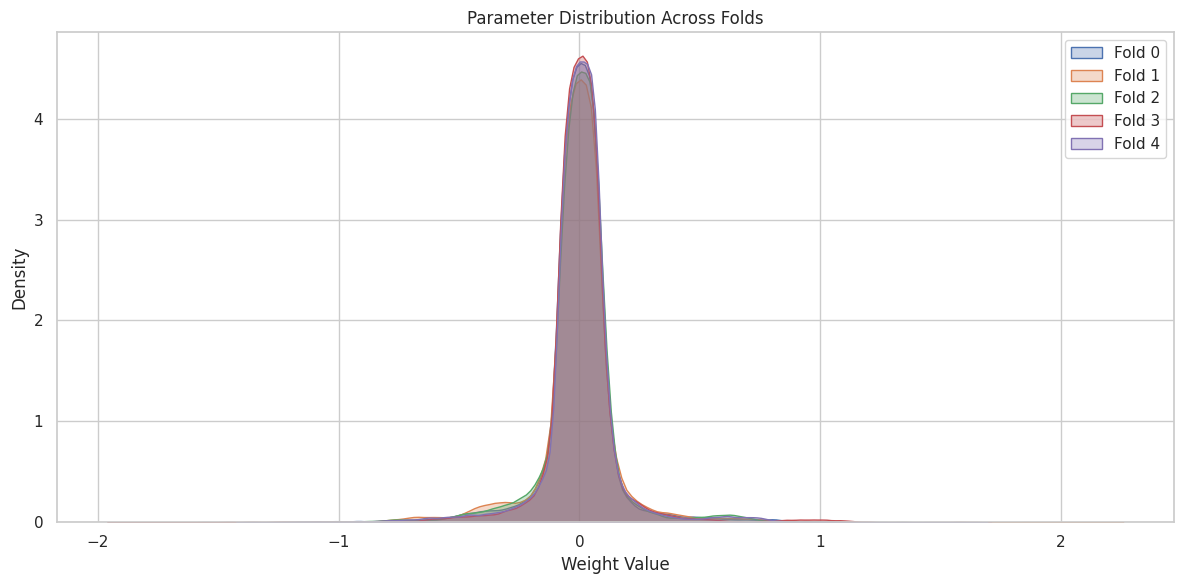

In [49]:
# Histogram showing variance of aggregated weights 
# Collect weights and plot kdes
all_weights = {f'Fold {i}': get_all_weights(model) for i, model in enumerate(models)}

plt.figure(figsize=(12, 6))
for fold, weights in all_weights.items():
    sns.kdeplot(weights, label=fold, fill=True, alpha=0.3)
plt.title('Parameter Distribution Across Folds')
plt.xlabel('Weight Value')
plt.ylabel('Density')
plt.legend()
plt.savefig("_images/parameter_distribution.png", dpi=300)
plt.tight_layout()
plt.show()

Seems all parameters vary tightly. How about a breakdown of each parameter across all folds?

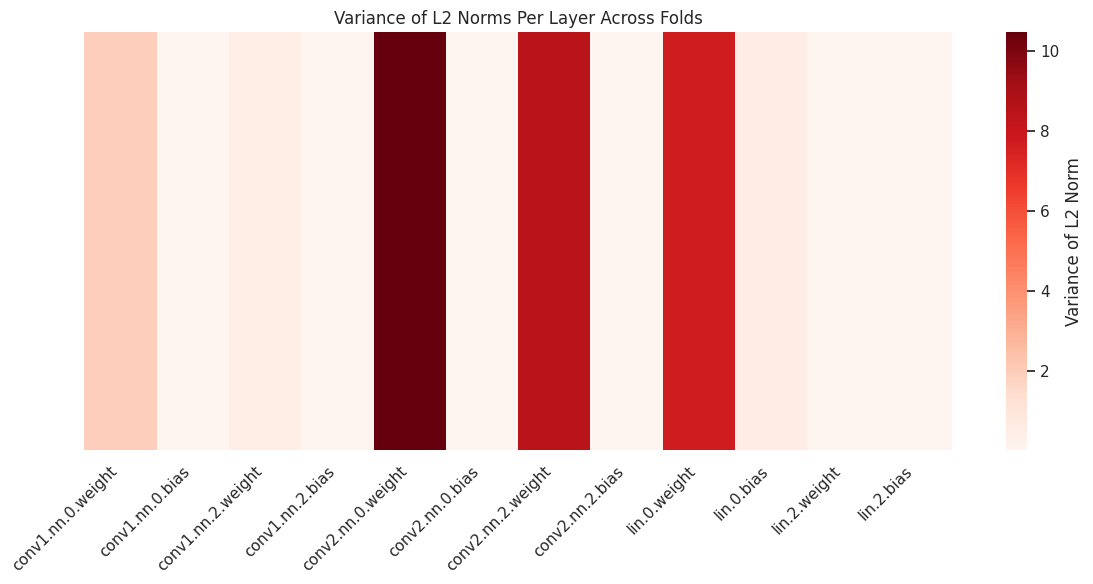

In [50]:
# Now let's have a look at each weight across all folds
# Collect norms for each model
norms_per_fold = {f'Fold {i}': get_weight_norms(model) for i, model in enumerate(models)}

df_norms = pd.DataFrame(norms_per_fold)

# Compute variance across folds per parameter
df_variance = df_norms.var(axis=1)

plt.figure(figsize=(12, 6))
sns.heatmap(df_variance.to_frame().T, cmap='Reds', cbar_kws={'label': 'Variance of L2 Norm'})
plt.yticks([])
plt.xticks(rotation=45, ha='right')
plt.title('Variance of L2 Norms Per Layer Across Folds')
plt.tight_layout()
plt.savefig("_images/l2_norm_variance.png", dpi=300)
plt.show()

Some evidence of variance over all folds in a few metrics. Let's show a breakdown by fold to locate how many folds are affected and by how much.

<Figure size 1400x600 with 0 Axes>

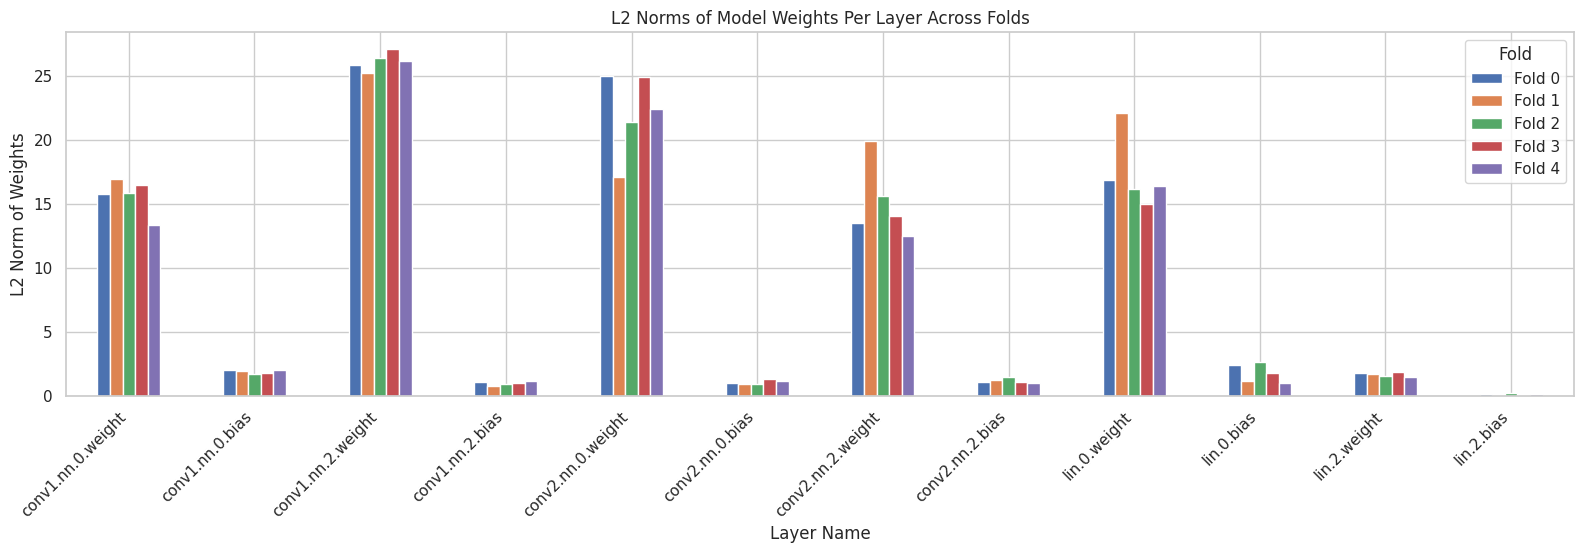

In [51]:
# Finally, let's look at the metrics per fold
num_folds = 5  
norms_per_fold = []

# TODO refactor so this isn't having to be loaded twice

for fold in range(num_folds):
    model = get_model()
    state_dict = torch.load(f'best_model_fold_{fold}.pth', map_location='cpu')
    model.load_state_dict(state_dict)
    model.eval()
    
    norms = get_weight_norms(model)
    norms_per_fold.append(norms)

df = pd.DataFrame(norms_per_fold)
df.index = [f'Fold {i}' for i in range(num_folds)]

plt.figure(figsize=(14, 6))
df.T.plot(kind='bar', figsize=(16, 6))
plt.title('L2 Norms of Model Weights Per Layer Across Folds')
plt.xlabel('Layer Name')
plt.ylabel('L2 Norm of Weights')
plt.grid(True)
plt.legend(title='Fold')
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.savefig("_images/weight_norms_comparison.png", dpi=300)
plt.show()

Fold 1 seems to be a conspicuously more accurate. Some indication of variation across folds in the second convolutional layer and also the final linear layer. 

To address the last one first, much as observed in the CYP model, `lin.0` is the first linear layer after global pooling, which means it's likely the first point of aggregation between node-level and global-level features. High variance of L2 norms across folds in this layer suggests the magnitude of learned weights is inconsistent. This is perhaps due to:

* Differences in graph-level feature importance across folds.
* Some folds relying more heavily on global features and others on pooled node features.
* Subtle instabilities in optimisation for this layer.

THe second convolutional layer is a little more concerning. `conv2` is applied after a ReLU from `conv1`, so it's acting on an already transformed feature space.
High variation here could suggest that this layer is doing a lot of feature disentangling, potentially due to insufficient expressive power earlier on or overfitting to local motifs. With respect to the `weight` parameter, if some folds have structurally richer or noisier molecules, this layer may adapt more drastically.

The GINConv is sensitive to node feature scale and, consequently, molecular size (due to its sum aggregation). There aren't a lot of larger molecules in the dataset, which can exacerbate the problem; their representation in mini-batches is inconsistent, so their gradient influence may dominate due to large activations. Consequently, the model may overfit to these outliers or fail to generalize properly.

In [52]:
for i, model in enumerate(models):
    norm = model.lin[0].weight.data.norm().item()
    print(f"Fold {i} - lin.0.weight L2 norm: {norm:.4f}")


Fold 0 - lin.0.weight L2 norm: 16.8541
Fold 1 - lin.0.weight L2 norm: 22.0951
Fold 2 - lin.0.weight L2 norm: 16.1628
Fold 3 - lin.0.weight L2 norm: 14.9444
Fold 4 - lin.0.weight L2 norm: 16.4145


If we're going to predict larger molecules, we can and should do some normalisation and stronger regularisation. However, given 4/5 of the folds have similar variance in this metric, we'll go with this model for now but cautiously.

In [53]:
torch.save({
    "model_state_dict": model.state_dict(),
    "input_dim": input_dim,
    "hidden_dim": hidden_dim,
    "global_feat_dim": global_feat_dim
    }, "caco2_abpapp_gin.pt")